In [1]:
import pandas as pd
import numpy as np
import random
import faker
namegen = faker.Faker()
from NewGame import *

pygame 2.6.1 (SDL 2.28.4, Python 3.13.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [4]:
BASECSV = pd.read_csv('teamsToUse.csv')
BASECSV

,Country,CountryABR,Team,TeamABR,LeaguePrestige,Budget,TIER,Region
0,United States,USA,New York,NYC,90,391,TIERA,Americas
1,United States,USA,Los Angeles,LAX,90,186,TIERA,Americas
2,United States,USA,Chicago,CHI,90,126,TIERA,Americas
3,United States,USA,Houston,HOU,90,108,TIERA,Americas
4,United States,USA,Phoenix,PHX,90,75,TIERA,Americas
...,...,...,...,...,...,...,...,...
1275,Oman,OMN,Al Khaburah,AKB,10,2,TIERE,MEA
1276,Oman,OMN,Saham,SAH,10,2,TIERE,MEA
1277,Oman,OMN,Al Khuwair,KHW,10,3,TIERE,MEA
1278,Oman,OMN,Seeb,SEB,10,13,TIERE,MEA


In [3]:
TotalSpots = 4*20*64
FreshmanClassProp = .25
OriginProps = [.3, .225, .3, .125, .05]
OriginAbsolutes = dict(zip(['TIERA', 'TIERB', 'TIERC', 'TIERD', 'TIERE'], 
                           [TotalSpots*FreshmanClassProp*prop/8 for prop in OriginProps[:2]]+[TotalSpots*FreshmanClassProp*prop/16 for prop in OriginProps[2:]]))
OriginAbsolutes

{'TIERA': 48.0, 'TIERB': 36.0, 'TIERC': 24.0, 'TIERD': 10.0, 'TIERE': 4.0}

In [ ]:
ALLROSTERED = pd.DataFrame(columns = ['League', 'Team', 'Country', 'Rating', 'Age', 'Years', 'AAV'])
TEAMSDF = pd.DataFrame(columns = ['Country', 'LeaguePrestige', 'TeamPrestige', 'TotalBudget'])
for teamrownum in range(len(BASECSV)):
    build = Team(BASECSV.loc[teamrownum, 'Team'], BASECSV.loc[teamrownum, 'TeamABR'])
    TEAMSDF.loc[build] = [BASECSV.loc[teamrownum, 'Team'], LeaguePrestigeLookup[CountryLookup[country]], build.prestige, build.budget]
TEAMSDF = TEAMSDF.sort_values(['TeamPrestige', 'TotalBudget'], ascending=False)
def Offseason(RosterDF, numloops = 1):
    for _ in range(numloops):
        print(_)
        for plyr in RosterDF.index:
            plyr.ageup()
            RosterDF.loc[plyr, 'Rating'] = plyr.rating
        RosterDF.Age += 1
        RosterDF.Years -= 1
        # Generate Rookies
        ROOKIEDF = pd.DataFrame(columns = ['Rating', 'Age', 'Country', 'League'])
        for country in TIERA+TIERB+TIERC+TIERD+TIERE:
            NumberToMake = OriginAbsolutes[CountryLookup[country]]
            for _ in range(int(NumberToMake)):
                build = Player(namegen.name_male(), country)
                ROOKIEDF.loc[build] = [build.rating, build.age, build.country, build.country]
        # Get Expiring Contracts
        EXPIREDF = RosterDF[RosterDF.Years==0][['Rating', 'Age', 'Country', 'League']]
        FADF = pd.concat([ROOKIEDF, EXPIREDF]).sort_values(['Rating', 'Age'], ascending=[False, True])
        RosterDF = RosterDF[RosterDF.Years!=0]
        NEEDSDF = TEAMSDF.merge(RosterDF.groupby(['Team'], sort = False).agg(Spent = ('AAV', 'sum'), NR = ('AAV', 'count')), how = 'left', left_index=True, right_index=True).fillna(0)
        NEEDSDF['PlayersNeeded'] = 4 - NEEDSDF.NR
        NEEDSDF['AvailableBudget'] = NEEDSDF.TotalBudget - NEEDSDF.Spent
        NEEDSDF = NEEDSDF[NEEDSDF.PlayersNeeded > 0][['Country', 'LeaguePrestige', 'TeamPrestige', 'PlayersNeeded', 'AvailableBudget']]
        while (len(NEEDSDF) != 0) and (len(FADF) != 0):
            CurPlayer = FADF.iloc[0]
            TFCP = NEEDSDF.copy()
            TFCP['YearsOffer'] = np.random.choice([1, 2, 3, 4, 5], len(NEEDSDF))
            TFCP['AAVOffer'] = TFCP.AvailableBudget*2/(TFCP.PlayersNeeded+1)
            TFCP['ContractScore'] = TFCP.AAVOffer**2*TFCP.YearsOffer
            TFCP.ContractScore = 100*TFCP.ContractScore/np.max(TFCP.ContractScore)
            TFCP['Score'] = CurPlayer.name.values['Contract']*TFCP.ContractScore + \
                CurPlayer.name.values['League Prestige']*TFCP.LeaguePrestige + \
                CurPlayer.name.values['Team Prestige']*TFCP.TeamPrestige + \
                CurPlayer.name.values['Home Nation']*100*(TFCP.Country == CurPlayer.Country) + \
                CurPlayer.name.values['Consistent Location']*100*(TFCP.Country == CurPlayer.League)
            Contract = TFCP.sort_values('Score', ascending=False).iloc[0]
            RosterDF.loc[CurPlayer.name] = Contract.Country, Contract.name, CurPlayer.Country, CurPlayer.Rating, CurPlayer.Age, Contract.YearsOffer, Contract.AAVOffer
            FADF.drop(CurPlayer.name, inplace = True)
            NEEDSDF.loc[Contract.name, 'PlayersNeeded'] -= 1
            NEEDSDF.loc[Contract.name, 'AvailableBudget'] -= Contract.AAVOffer
            NEEDSDF = NEEDSDF[NEEDSDF.PlayersNeeded > 0]
    return RosterDF.sort_values('Rating', ascending = False)

In [ ]:
ALLROSTERED = Offseason(ALLROSTERED, numloops=10)

,League,Team,Country,Rating,Age,Years,AAV
Sergio Sosa,Spain,Spain #18,Colombia,97.656942,5,1,6.143034
Brian Wright,United Kingdom,United Kingdom #1,Brazil,95.109545,7,4,31.250081
Jeremy Perry,Netherlands,Netherlands #13,Japan,94.373095,6,2,8.213161
Casey Lee,Germany,Germany #2,United Arab Emirates,93.345209,7,3,23.880495
Thomas Butler,Japan,Japan #9,United Kingdom,91.695816,7,2,32.420562
...,...,...,...,...,...,...,...
William Russell,Peru,Peru #13,Switzerland,23.296713,10,1,0.235864
Calvin Chase,Canada,Canada #6,Pakistan,23.169153,10,1,5.827990
Anthony Sexton,Indonesia,Indonesia #6,Argentina,22.948146,10,1,3.041455
William Schroeder,Indonesia,Indonesia #4,Germany,22.346187,10,1,3.469599


In [ ]:
ALLROSTERED

0


C:\Users\HerzigAW\AppData\Local\Temp\ipykernel_3624\251938106.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  FADF = pd.concat([ROOKIEDF, EXPIREDF]).sort_values(['Rating', 'Age'], ascending=[False, True])
C:\Users\HerzigAW\AppData\Local\Temp\ipykernel_3624\251938106.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  NEEDSDF = TEAMSDF.merge(RosterDF.groupby(['Team'], sort = False).agg(Spent = ('AAV', 'sum'), NR = ('AAV', 'count')), how = 'left', left_index=True, right_index=True).fillna(0)


1
2
3
4
5
6
7
8
9


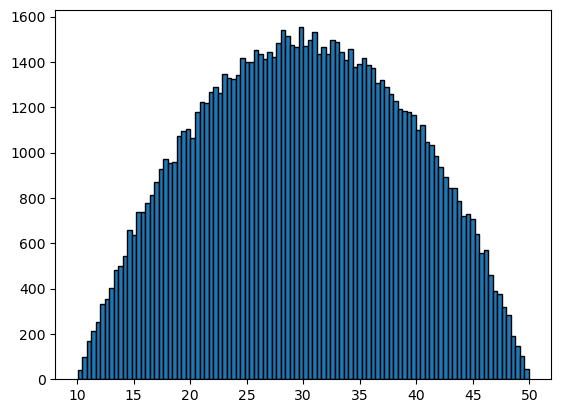

In [121]:
import matplotlib.pyplot as plt
def adjustDraw(mu, rng):
    return mu + 2*rng*(np.random.beta(2, 2)-.5)
data = np.array([adjustDraw(30, 20) for _ in range(100000)])
#data = 30 + 2*20*(np.random.beta(2, 2, 100000)-.5)
counts, bin_edges = np.histogram(data, bins=100)
plt.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), align='edge', edgecolor='black')
plt.show()